In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets
from sklearn.metrics import f1_score

In [2]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [15]:
# Contar cuántas muestras hay por cada clase (0, 1, 2)
valores, conteos = np.unique(target, return_counts=True)

for val, count in zip(valores, conteos):
    print(f"Clase {val}: {count} muestras")

Clase 0: 50 muestras
Clase 1: 50 muestras
Clase 2: 50 muestras


In [3]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [4]:
model = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer2"),
  ]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
y = model(X)
print(y[149])

tf.Tensor([0.35906318 0.5816659  0.23813127], shape=(3,), dtype=float32)


In [6]:
optimizer=tf.keras.optimizers.SGD(learning_rate=0.03)
loss=tf.keras.losses.MeanSquaredError()

model.compile(optimizer, loss)
history = model.fit(X, Y, epochs=500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2479  
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2471 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2464 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2456 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2449 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2442 
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2435 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2428  
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2422 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2415 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2409 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2403 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2398 
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2392 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2386 
Epoch 16/500
5/5 

In [7]:
model.predict(np.array([[3,3,1,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


array([[0.44856054, 0.31044757, 0.39420795]], dtype=float32)

In [9]:
def keras_training_f1_score(model_to_eval, X, target):
  predictions = model_to_eval.predict(X, verbose=0)
  predicted_classes = np.argmax(predictions, axis=1)
  # Use average='weighted' to account for label imbalance
  return f1_score(target, predicted_classes, average='weighted')

sampled losses
epoch 000 loss=0.247897
epoch 050 loss=0.227628
epoch 100 loss=0.223558
epoch 150 loss=0.222475
epoch 200 loss=0.221930
epoch 250 loss=0.221477
epoch 300 loss=0.220943
epoch 350 loss=0.220229
epoch 400 loss=0.219233
epoch 450 loss=0.217770
epoch 500 loss=0.215725
final loss=0.215725
accuracy=0.5000
f1_score=0.3990
prediction [3, 3, 1, 1] =
[[0.44856054 0.31044757 0.39420795]]


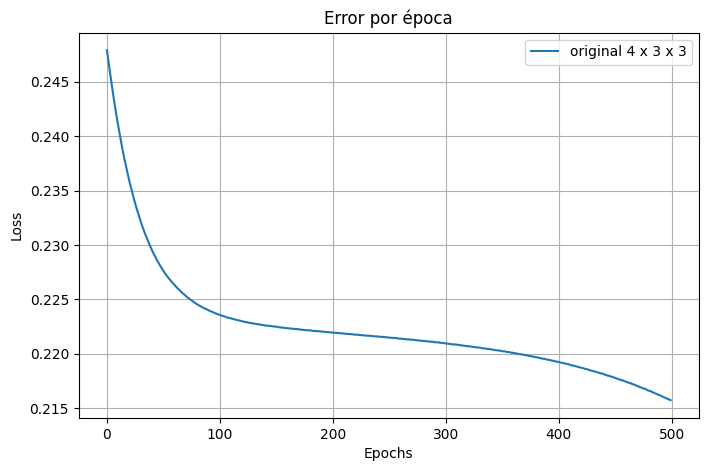

In [10]:
def keras_training_accuracy(model_to_eval, X, target):
  predictions = model_to_eval.predict(X, verbose=0)
  predicted_classes = np.argmax(predictions, axis=1)
  return np.mean(predicted_classes == target)

print("sampled losses")
for epoch in range(0, len(history.history["loss"]), 50):
  print(f"epoch {epoch:03d} loss={history.history['loss'][epoch]:.6f}")
last_epoch = len(history.history["loss"]) - 1
if last_epoch % 50 != 0:
  print(f"epoch {last_epoch + 1:03d} loss={history.history['loss'][-1]:.6f}")

print(f"final loss={history.history['loss'][-1]:.6f}")
accuracy_original = keras_training_accuracy(model, X, target)
f1_original = keras_training_f1_score(model, X, target)
print(f"accuracy={accuracy_original:.4f}")
print(f"f1_score={f1_original:.4f}")
print("prediction [3, 3, 1, 1] =")
print(model.predict(np.array([[3, 3, 1, 1]]), verbose=0))

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="original 4 x 3 x 3")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Error por época")
plt.legend()
plt.grid(True)
plt.show()

## Red profunda Keras: topologia 4 x 3 x 3 x 3 x 3

Estas celdas nuevas agregan exactamente dos capas ocultas antes de la salida.

In [11]:
keras.utils.set_random_seed(7)

model_deep = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="deep_layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="deep_layer2"),
    layers.Dense(3, activation="sigmoid", name="deep_layer3"),
    layers.Dense(3, activation="sigmoid", name="deep_layer4"),
  ]
)

model_deep.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ deep_layer1 (Dense)             │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_layer2 (Dense)             │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_layer3 (Dense)             │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_layer4 (Dense)             │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

sampled losses
epoch 000 loss=0.304207
epoch 050 loss=0.250534
epoch 100 loss=0.231507
epoch 150 loss=0.225566
epoch 200 loss=0.223572
epoch 250 loss=0.222848
epoch 300 loss=0.222571
epoch 350 loss=0.222461
epoch 400 loss=0.222416
epoch 450 loss=0.222399
epoch 500 loss=0.222392
final loss=0.222392
accuracy=0.3333
f1_score=0.1667
training_time_seconds=31.9297
prediction [3, 3, 1, 1] =
[[0.35250437 0.33001715 0.3245209 ]]


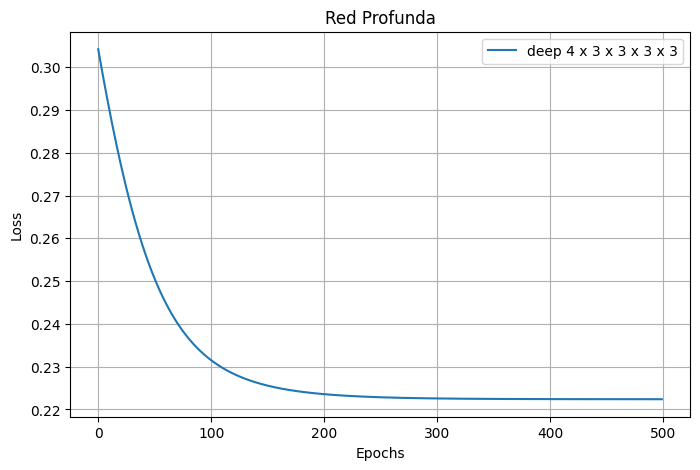

In [12]:
import time

optimizer_deep = tf.keras.optimizers.SGD(learning_rate=0.03)
loss_deep = tf.keras.losses.MeanSquaredError()

model_deep.compile(optimizer_deep, loss_deep)
start_time = time.perf_counter()
history_deep = model_deep.fit(X, Y, epochs=500, verbose=0)
training_time_keras_deep = time.perf_counter() - start_time

print("sampled losses")
for epoch in range(0, len(history_deep.history["loss"]), 50):
  print(f"epoch {epoch:03d} loss={history_deep.history['loss'][epoch]:.6f}")
last_epoch = len(history_deep.history["loss"]) - 1
if last_epoch % 50 != 0:
  print(f"epoch {last_epoch + 1:03d} loss={history_deep.history['loss'][-1]:.6f}")

print(f"final loss={history_deep.history['loss'][-1]:.6f}")
accuracy_deep = keras_training_accuracy(model_deep, X, target)
f1_deep = keras_training_f1_score(model_deep, X, target)
print(f"accuracy={accuracy_deep:.4f}")
print(f"f1_score={f1_deep:.4f}")
print(f"training_time_seconds={training_time_keras_deep:.4f}")
print("prediction [3, 3, 1, 1] =")
print(model_deep.predict(np.array([[3, 3, 1, 1]]), verbose=0))

plt.figure(figsize=(8, 5))
plt.plot(history_deep.history["loss"], label="deep 4 x 3 x 3 x 3 x 3")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Red Profunda")
plt.legend()
plt.grid(True)
plt.show()

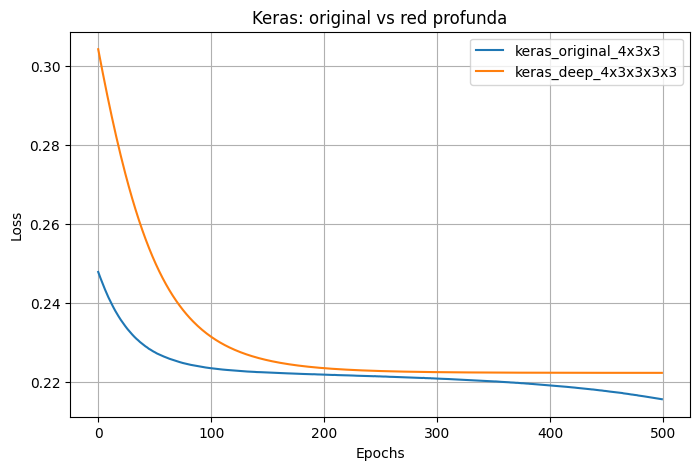

Keras final losses
keras_original_4x3x3    0.215725
keras_deep_4x3x3x3x3    0.222392
Name: 499, dtype: float64


In [13]:
comparison = pd.DataFrame(
  {
    "keras_original_4x3x3": history.history["loss"],
    "keras_deep_4x3x3x3x3": history_deep.history["loss"],
  }
)
ax = comparison.plot(figsize=(8, 5), title="Keras: original vs red profunda")
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.grid(True)
plt.show()

print("Keras final losses")
print(comparison.iloc[-1])

## Análisis de estabilidad del loss con 30 corridas - Keras

Esta seccion entrena desde cero 30 veces la red original `4 x 3 x 3` y la red
profunda `4 x 3 x 3 x 3 x 3`. Se mantienen sigmoide, MSE, SGD con
`learning_rate = 0.03` y 500 epocas. Cada corrida usa una semilla distinta.

In [16]:
import time

KERAS_STABILITY_RUNS = 30
KERAS_STABILITY_EPOCHS = 500
KERAS_STABILITY_LR = 0.03
KERAS_STABILITY_BASE_SEED = 2026

def build_keras_mlp(layer_count, seed):
  keras.utils.set_random_seed(seed)
  model_stability = keras.Sequential()
  # Explicitly add an Input layer as recommended
  model_stability.add(keras.Input(shape=(4,), name="input_layer"))
  model_stability.add(layers.Dense(3, activation="sigmoid", name="layer1"))
  for layer_idx in range(2, layer_count + 1):
    model_stability.add(layers.Dense(3, activation="sigmoid", name=f"layer{layer_idx}"))

  model_stability.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=KERAS_STABILITY_LR),
    loss=tf.keras.losses.MeanSquaredError(),
  )
  return model_stability

def accuracy_keras_stability(model_to_eval):
  predictions = model_to_eval.predict(X, verbose=0)
  predicted_classes = np.argmax(predictions, axis=1)
  return np.mean(predicted_classes == target)

def train_keras_once(layer_count, seed):
  model_stability = build_keras_mlp(layer_count, seed)
  history_stability = model_stability.fit(
    X,
    Y,
    epochs=KERAS_STABILITY_EPOCHS,
    verbose=0,
    shuffle=True,
  )
  return {
    "seed": seed,
    "final_loss": history_stability.history["loss"][-1],
    "accuracy": accuracy_keras_stability(model_stability),
    "losses": history_stability.history["loss"],
  }

def summarize_keras_stability(label, results):
  final_losses = np.asarray([r["final_loss"] for r in results])
  accuracies = np.asarray([r["accuracy"] for r in results])
  print(f"\nResumen {label}")
  print(f"runs={len(results)} epochs={KERAS_STABILITY_EPOCHS} learning_rate={KERAS_STABILITY_LR}")
  print(f"final_loss_mean={final_losses.mean():.6f}")
  print(f"final_loss_std={final_losses.std(ddof=1):.6f}")
  print(f"final_loss_min={final_losses.min():.6f}")
  print(f"final_loss_max={final_losses.max():.6f}")
  print(f"accuracy_mean={accuracies.mean():.4f}")
  print(f"accuracy_std={accuracies.std(ddof=1):.4f}")
  print(f"accuracy_min={accuracies.min():.4f}")
  print(f"accuracy_max={accuracies.max():.4f}")

def run_keras_stability():
  original_results = []
  deep_results = []
  start_time = time.perf_counter()

  for run_idx in range(KERAS_STABILITY_RUNS):
    seed = KERAS_STABILITY_BASE_SEED + run_idx
    original = train_keras_once(layer_count=2, seed=seed)
    deep = train_keras_once(layer_count=4, seed=seed)
    original_results.append(original)
    deep_results.append(deep)
    print(
      f"run {run_idx + 1:02d}/{KERAS_STABILITY_RUNS} seed={seed} "
      f"original_loss={original['final_loss']:.6f} original_acc={original['accuracy']:.4f} "
      f"deep_loss={deep['final_loss']:.6f} deep_acc={deep['accuracy']:.4f}"
    )

  elapsed = time.perf_counter() - start_time
  summarize_keras_stability("Keras original 4 x 3 x 3", original_results)
  summarize_keras_stability("Keras deep 4 x 3 x 3 x 3 x 3", deep_results)
  print(f"\nKeras stability total_time_seconds={elapsed:.4f}")

  return original_results, deep_results

keras_original_30, keras_deep_30 = run_keras_stability()

run 01/30 seed=2026 original_loss=0.184790 original_acc=0.6667 deep_loss=0.222360 deep_acc=0.3333
run 02/30 seed=2027 original_loss=0.221318 original_acc=0.3333 deep_loss=0.222179 deep_acc=0.3333
run 03/30 seed=2028 original_loss=0.152256 original_acc=0.6733 deep_loss=0.222465 deep_acc=0.3333
run 04/30 seed=2029 original_loss=0.157147 original_acc=0.6667 deep_loss=0.222258 deep_acc=0.3333
run 05/30 seed=2030 original_loss=0.179299 original_acc=0.6667 deep_loss=0.220330 deep_acc=0.6667
run 06/30 seed=2031 original_loss=0.154778 original_acc=0.6667 deep_loss=0.221646 deep_acc=0.3333
run 07/30 seed=2032 original_loss=0.155377 original_acc=0.6667 deep_loss=0.221688 deep_acc=0.3333
run 08/30 seed=2033 original_loss=0.180469 original_acc=0.6667 deep_loss=0.218213 deep_acc=0.6667
run 09/30 seed=2034 original_loss=0.151440 original_acc=0.6667 deep_loss=0.217927 deep_acc=0.3333
run 10/30 seed=2035 original_loss=0.152779 original_acc=0.7667 deep_loss=0.222124 deep_acc=0.3333
run 11/30 seed=2036 

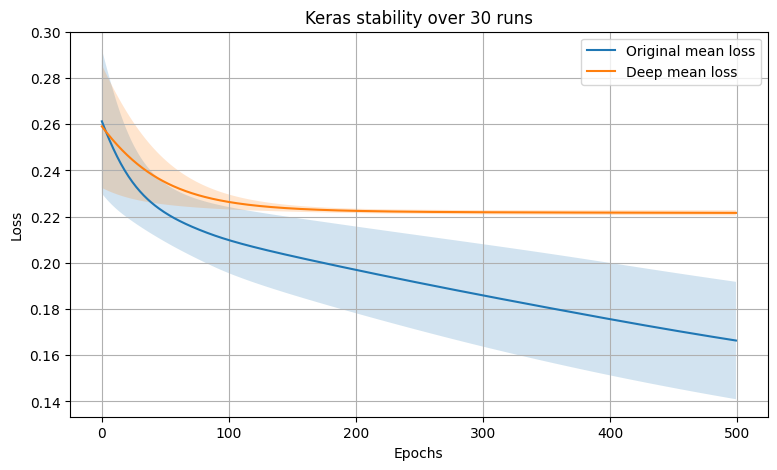

/tmp/ipykernel_5327/3676968209.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


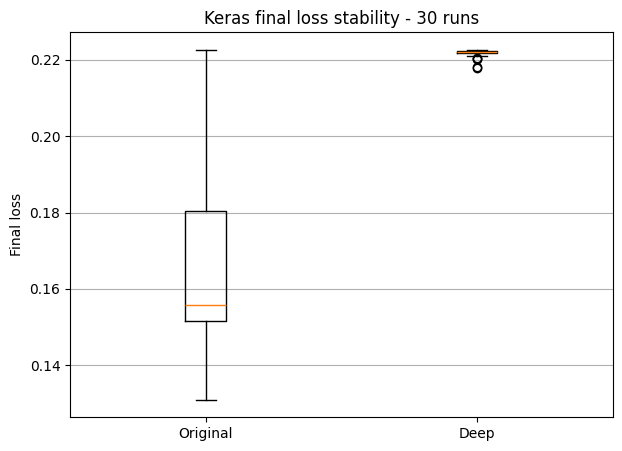

Keras stability describe
       keras_original_final_loss  keras_deep_final_loss  \
count                  30.000000              30.000000   
mean                    0.166381               0.221619   
std                     0.025838               0.001150   
min                     0.130981               0.217927   
25%                     0.151546               0.221657   
50%                     0.155680               0.222132   
75%                     0.180501               0.222261   
max                     0.222563               0.222614   

       keras_original_accuracy  keras_deep_accuracy  
count                30.000000            30.000000  
mean                  0.648000             0.367778  
std                   0.092233             0.101424  
min                   0.333333             0.333333  
25%                   0.666667             0.333333  
50%                   0.666667             0.333333  
75%                   0.671667             0.333333  
max        

In [17]:
keras_original_curves = np.asarray([r["losses"] for r in keras_original_30])
keras_deep_curves = np.asarray([r["losses"] for r in keras_deep_30])

plt.figure(figsize=(9, 5))
plt.plot(keras_original_curves.mean(axis=0), label="Original mean loss")
plt.fill_between(
  np.arange(keras_original_curves.shape[1]),
  keras_original_curves.mean(axis=0) - keras_original_curves.std(axis=0),
  keras_original_curves.mean(axis=0) + keras_original_curves.std(axis=0),
  alpha=0.20,
)
plt.plot(keras_deep_curves.mean(axis=0), label="Deep mean loss")
plt.fill_between(
  np.arange(keras_deep_curves.shape[1]),
  keras_deep_curves.mean(axis=0) - keras_deep_curves.std(axis=0),
  keras_deep_curves.mean(axis=0) + keras_deep_curves.std(axis=0),
  alpha=0.20,
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Keras stability over 30 runs")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.boxplot(
  [
    [r["final_loss"] for r in keras_original_30],
    [r["final_loss"] for r in keras_deep_30],
  ],
  labels=["Original", "Deep"],
)
plt.ylabel("Final loss")
plt.title("Keras final loss stability - 30 runs")
plt.grid(True, axis="y")
plt.show()

stability_summary = pd.DataFrame(
  {
    "keras_original_final_loss": [r["final_loss"] for r in keras_original_30],
    "keras_deep_final_loss": [r["final_loss"] for r in keras_deep_30],
    "keras_original_accuracy": [r["accuracy"] for r in keras_original_30],
    "keras_deep_accuracy": [r["accuracy"] for r in keras_deep_30],
  }
)
print("Keras stability describe")
print(stability_summary.describe())

## Reto opcional: ReLU + softmax y más neuronas ocultas
En esta sección se comparan tres redes profundas de Keras sobre el mismo split
entrenamiento/prueba:

- `4 x 3 x 3 x 3 x 3` con sigmoide + MSE.
- `4 x 3 x 3 x 3 x 3` con ReLU en ocultas, softmax en salida y
  `categorical_crossentropy`.
- `4 x 8 x 8 x 8 x 3` con ReLU en ocultas, softmax en salida y
  `categorical_crossentropy`.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

RETO_EPOCHS = 500
RETO_LR = 0.03
RETO_SEED = 2026

X_train, X_test, y_train, y_test, Y_train, Y_test = train_test_split(
  X,
  target,
  Y,
  test_size=0.20,
  random_state=RETO_SEED,
  stratify=target,
)

print("Reto opcional Keras")
print("Train samples:", len(X_train))
print("Test samples:", len(X_test))
print("Epocas:", RETO_EPOCHS)
print("Learning rate:", RETO_LR)
print("Seed:", RETO_SEED)

Reto opcional Keras
Train samples: 120
Test samples: 30
Epocas: 500
Learning rate: 0.03
Seed: 2026


In [19]:
def build_reto_model(hidden_units, hidden_activation, output_activation, loss_fn, seed, name):
  keras.utils.set_random_seed(seed)
  reto_model = keras.Sequential(name=name)
  reto_model.add(keras.Input(shape=(4,), name=f"{name}_input"))

  for idx, units in enumerate(hidden_units, start=1):
    reto_model.add(
      layers.Dense(
        units,
        activation=hidden_activation,
        name=f"{name}_hidden{idx}",
      )
    )

  reto_model.add(
    layers.Dense(
      3,
      activation=output_activation,
      name=f"{name}_output",
    )
  )

  reto_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=RETO_LR),
    loss=loss_fn,
    metrics=["accuracy"],
  )
  return reto_model

def train_reto_variant(label, hidden_units, hidden_activation, output_activation, loss_fn, seed_offset=0):
  print("\n" + "=" * 72)
  print(label)
  print("hidden_units:", hidden_units)
  print("hidden_activation:", hidden_activation)
  print("output_activation:", output_activation)
  print("loss:", loss_fn)

  reto_model = build_reto_model(
    hidden_units=hidden_units,
    hidden_activation=hidden_activation,
    output_activation=output_activation,
    loss_fn=loss_fn,
    seed=RETO_SEED + seed_offset,
    name=label.lower().replace(" ", "_").replace("+", "plus"),
  )
  reto_model.summary()

  start_time = time.perf_counter()
  reto_history = reto_model.fit(
    X_train,
    Y_train,
    validation_data=(X_test, Y_test),
    epochs=RETO_EPOCHS,
    verbose=0,
    shuffle=True,
  )
  elapsed = time.perf_counter() - start_time

  train_pred = np.argmax(reto_model.predict(X_train, verbose=0), axis=1)
  test_pred = np.argmax(reto_model.predict(X_test, verbose=0), axis=1)

  final_train_loss = reto_history.history["loss"][-1]
  final_val_loss = reto_history.history["val_loss"][-1]
  train_acc = accuracy_score(y_train, train_pred)
  test_acc = accuracy_score(y_test, test_pred)
  test_f1 = f1_score(y_test, test_pred, average="weighted")
  overfit_gap = train_acc - test_acc

  print(f"{label} final_train_loss={final_train_loss:.6f}")
  print(f"{label} final_val_loss={final_val_loss:.6f}")
  print(f"{label} train_accuracy={train_acc:.4f}")
  print(f"{label} test_accuracy={test_acc:.4f}")
  print(f"{label} test_f1_weighted={test_f1:.4f}")
  print(f"{label} overfit_gap_train_minus_test={overfit_gap:.4f}")
  print(f"{label} training_time_seconds={elapsed:.4f}")
  print(f"{label} sampled losses:")
  for epoch in range(0, RETO_EPOCHS, 50):
    train_loss = reto_history.history["loss"][epoch]
    val_loss = reto_history.history["val_loss"][epoch]
    print(f"  epoch {epoch + 1:03d}: loss={train_loss:.6f} val_loss={val_loss:.6f}")
  print(
    f"  epoch {RETO_EPOCHS:03d}: "
    f"loss={final_train_loss:.6f} val_loss={final_val_loss:.6f}"
  )

  return {
    "label": label,
    "model": reto_model,
    "history": reto_history,
    "final_train_loss": final_train_loss,
    "final_val_loss": final_val_loss,
    "train_accuracy": train_acc,
    "test_accuracy": test_acc,
    "test_f1_weighted": test_f1,
    "overfit_gap": overfit_gap,
    "training_time_seconds": elapsed,
  }

In [20]:
reto_sigmoid_mse = train_reto_variant(
  label="Deep sigmoid MSE 3",
  hidden_units=[3, 3, 3],
  hidden_activation="sigmoid",
  output_activation="sigmoid",
  loss_fn=tf.keras.losses.MeanSquaredError(),
  seed_offset=0,
)

reto_relu_softmax = train_reto_variant(
  label="Deep ReLU softmax 3",
  hidden_units=[3, 3, 3],
  hidden_activation="relu",
  output_activation="softmax",
  loss_fn=tf.keras.losses.CategoricalCrossentropy(),
  seed_offset=1,
)

reto_wide_relu_softmax = train_reto_variant(
  label="Wide ReLU softmax 8",
  hidden_units=[8, 8, 8],
  hidden_activation="relu",
  output_activation="softmax",
  loss_fn=tf.keras.losses.CategoricalCrossentropy(),
  seed_offset=2,
)


Deep sigmoid MSE 3
hidden_units: [3, 3, 3]
hidden_activation: sigmoid
output_activation: sigmoid
loss: <LossFunctionWrapper(<function mean_squared_error at 0x7e59d3b12700>, kwargs={})>


Model: "deep_sigmoid_mse_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ deep_sigmoid_mse_3_hidden1      │ (None, 3)              │            15 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_sigmoid_mse_3_hidden2      │ (None, 3)              │            12 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_sigmoid_mse_3_hidden3      │ (None, 3)              │            12 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_sigmoid_mse_3_output       │ (None, 3)              │            12 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ wide_relu_softmax_8_hidden1     │ (None, 8)              │            40 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ wide_relu_softmax_8_hidden2     │ (None, 8)              │            72 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ wide_relu_softmax_8_hidden3     │ (None, 8)              │            72 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ wide_relu_softmax_8_output      │ (None, 3)              │            27 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211 (844.00 B)

 Trainable params: 211 (844.00 B)

 Non-trainable params: 0 (0.00 B)

Wide ReLU softmax 8 final_train_loss=0.067387
Wide ReLU softmax 8 final_val_loss=0.095511
Wide ReLU softmax 8 train_accuracy=0.9833
Wide ReLU softmax 8 test_accuracy=0.9333
Wide ReLU softmax 8 test_f1_weighted=0.9327
Wide ReLU softmax 8 overfit_gap_train_minus_test=0.0500
Wide ReLU softmax 8 training_time_seconds=62.0723
Wide ReLU softmax 8 sampled losses:
  epoch 001: loss=1.103622 val_loss=1.045241
  epoch 051: loss=0.322975 val_loss=0.262245
  epoch 101: loss=0.129218 val_loss=0.118816
  epoch 151: loss=0.084480 val_loss=0.092938
  epoch 201: loss=0.077278 val_loss=0.091756
  epoch 251: loss=0.070361 val_loss=0.095649
  epoch 301: loss=0.106253 val_loss=0.106189
  epoch 351: loss=0.076800 val_loss=0.083204
  epoch 401: loss=0.082104 val_loss=0.085792
  epoch 451: loss=0.076855 val_loss=0.088501
  epoch 500: loss=0.067387 val_loss=0.095511


In [21]:
reto_results = [reto_sigmoid_mse, reto_relu_softmax, reto_wide_relu_softmax]

reto_summary = pd.DataFrame(
  [
    {
      "modelo": result["label"],
      "train_loss": result["final_train_loss"],
      "val_loss": result["final_val_loss"],
      "train_accuracy": result["train_accuracy"],
      "test_accuracy": result["test_accuracy"],
      "test_f1_weighted": result["test_f1_weighted"],
      "overfit_gap": result["overfit_gap"],
      "seconds": result["training_time_seconds"],
    }
    for result in reto_results
  ]
)

print("Resumen reto opcional")
print(reto_summary)

best_test = reto_summary.sort_values("test_accuracy", ascending=False).iloc[0]
print("\nMejor test_accuracy:", best_test["modelo"], f"{best_test['test_accuracy']:.4f}")

Resumen reto opcional
                modelo  train_loss  val_loss  train_accuracy  test_accuracy  \
0   Deep sigmoid MSE 3    0.222366  0.222351        0.333333       0.333333   
1  Deep ReLU softmax 3    1.098825  1.098685        0.333333       0.333333   
2  Wide ReLU softmax 8    0.067387  0.095511        0.983333       0.933333   

   test_f1_weighted  overfit_gap    seconds  
0          0.166667         0.00  88.645762  
1          0.166667         0.00  66.550659  
2          0.932660         0.05  62.072289  

Mejor test_accuracy: Wide ReLU softmax 8 0.9333


In [22]:

print("\nInterpretacion rapida:")
print("- Si ReLU + softmax baja mas la val_loss y sube test_accuracy, mejoro la optimizacion.")
print("- Si la red 8-8-8 sube train_accuracy pero no test_accuracy, hay senal de sobreajuste.")
print("- Si train_accuracy y test_accuracy suben juntas, Iris si se beneficio de mas neuronas.")


Interpretacion rapida:
- Si ReLU + softmax baja mas la val_loss y sube test_accuracy, mejoro la optimizacion.
- Si la red 8-8-8 sube train_accuracy pero no test_accuracy, hay senal de sobreajuste.
- Si train_accuracy y test_accuracy suben juntas, Iris si se beneficio de mas neuronas.
